In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
nr_of_seeds = 10 #nr of seeds in the experiments

In [3]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [4]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3888\1466190064.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3888\1466190064.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

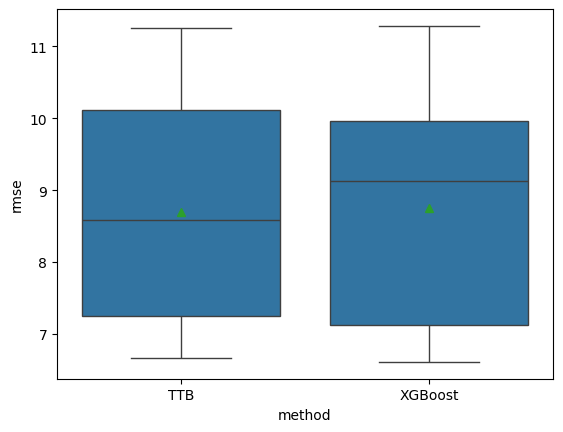

In [5]:


dat = pd.read_csv(f'results/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [6]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
697,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,859.0,400.0,6.111754,4.249241,11.248198,7.558559,TransferTreeBoost
57,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,850.0,400.0,8.557071,5.184391,7.109236,5.364227,TransferTreeBoost
582,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,858.0,400.0,7.807352,5.396233,10.022158,5.652553,TransferTreeBoost
521,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,857.0,400.0,7.835177,5.600413,9.128745,5.658247,TransferTreeBoost
97,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,851.0,400.0,7.203495,4.454950,10.150565,5.866001,TransferTreeBoost
473,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,856.0,400.0,7.036850,5.530224,10.154769,5.463990,TransferTreeBoost
257,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,853.0,400.0,8.030415,5.527365,6.762229,4.810999,TransferTreeBoost
369,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,855.0,400.0,5.380653,4.154774,8.045069,4.463023,TransferTreeBoost
185,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,852.0,400.0,7.276444,5.368780,6.670058,5.085707,TransferTreeBoost
310,0.1,2.0,1.0,0.0,0.5,8.696597,5.502175,10,854.0,400.0,7.275159,4.976611,7.674938,5.098445,TransferTreeBoost


In [7]:
lk

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
0,0.1,1.0,8.754744,5.557233,10,0,850.0,9.124113,5.516504,6.898711,5.128034,XGBoost
6,0.1,1.0,8.754744,5.557233,10,6,851.0,7.314470,4.669689,9.961212,5.901499,XGBoost
12,0.1,1.0,8.754744,5.557233,10,12,852.0,7.489444,5.410438,6.750502,5.173989,XGBoost
18,0.1,1.0,8.754744,5.557233,10,18,853.0,7.786895,5.575127,6.613367,4.896775,XGBoost
24,0.1,1.0,8.754744,5.557233,10,24,854.0,7.411450,5.153226,7.801493,5.206268,XGBoost
30,0.1,1.0,8.754744,5.557233,10,30,855.0,5.815372,4.766745,8.565021,4.676606,XGBoost
42,0.1,1.0,8.754744,5.557233,10,42,857.0,7.875071,5.622582,9.681741,5.935399,XGBoost
36,0.1,1.0,8.754744,5.557233,10,36,856.0,7.414108,5.775653,10.028588,5.392999,XGBoost
48,0.1,1.0,8.754744,5.557233,10,48,858.0,7.890879,5.621195,9.965104,5.731219,XGBoost
54,0.1,1.0,8.754744,5.557233,10,54,859.0,6.022428,4.225420,11.281697,7.529540,XGBoost
